# Quick Start

This notebook gives a minimal end-to-end example: build a `ConvolsData` field from particle positions, smooth the fluctuation field, and estimate a simple two-point statistic from shell convolutions.


In [1]:
from pyhermes.base.convols import Convols
from pyhermes.param.parambase import read_param
from pyhermes.io import WindowFunc
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path
import os
os.chdir(Path.cwd().resolve().parent)
print(f"Working directory: {Path.cwd()}")

Working directory: /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples


22:13:13 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_convols.yaml'
22:13:13 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
22:13:13 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
22:13:13 - INFO - pyhermes.param.parambase:ParamBase - Default 'Convols.fin.path' from 'empty' to './data/quijote_halos/8000'
22:13:13 - INFO - pyhermes.param.parambase:ParamBase - Default 'Convols.fin.format' from 'bin' to 'fof'
22:13:13 - WARNING - pyhermes.param.parambase:ParamBase - Adding non-default key: 'Convols.fin.reader_params.snapnum'
22:13:13 - INFO - pyhermes.param.parambase:ParamBase - Default 'Convols.threads' from '1' to '2'
22:13:13 - INFO - pyhermes.param.parambase:ParamBase - Default 'Convols.save_particle_data' from 'False' to 'True'
22:13:13 - INFO - pyhermes.param.parambase:ParamBase - Default 'Convols.particle_data_path' from 'empty' to './data/quijote_halos/8000/group

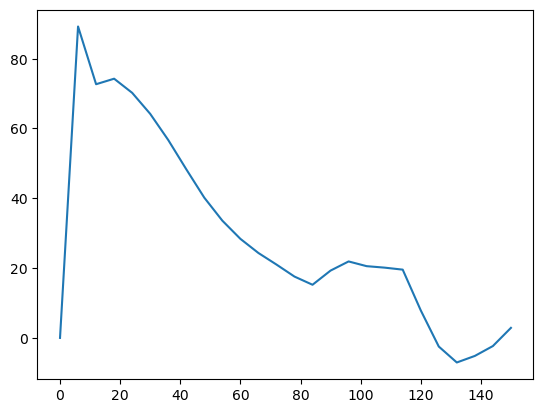

In [2]:
# Step 1: build the multiresolution coefficient field from particle positions
task_params = read_param(config_path="./configs/param_convols.yaml")
D = Convols(task_params).run()
D.threads = 8

# Step 2: construct the fluctuation field delta = D - R
rho = 1 / D.V # uniform random field in the same normalized convention
RR = rho ** 2 # <RR>, used to normalize the 2PCF estimator
deltaD = D - rho # fluctuation field, i.e. the overdensity-like field

# Step 3: smooth the fluctuation field with a spherical window
win_params = {"type": "sphere", "len_args": {"R": 5}} # spherical top-hat window of radius 5
win_filter = WindowFunc(win_params, D.convols_info, threads=8)
deltaD_w = deltaD @ win_filter # smoothed fluctuation field

# Step 4: measure xi(r) by shell convolution + spatial averaging
# DD(r) = <n(x)n(x+r)>; n(x+r) = n_r(x) = n(x) @ W_shell(r)
# \xi = (D-R)(D-R)/RR
r_arr = np.linspace(0, 150, 26)
xi_arr = np.zeros_like(r_arr)
for i, r in enumerate(r_arr):
    pair_win_params = {"type": "shell", "len_args": {"R": r}}
    pair_win_shell = WindowFunc(pair_win_params, D.convols_info, threads=8)
    deltaDD_w = deltaD_w @ pair_win_shell * deltaD_w # shell-convolved field multiplied by the original field
    xi_arr[i] = deltaDD_w.as_array().mean() / RR # spatial mean gives xi(r) after normalization by RR

plt.plot(r_arr, xi_arr * r_arr**2)
plt.show()